# Percobaan 1: Cluster Fuzzy C Means LIB(FCM)

In [ ]:
!pip install scikit-fuzzy

!pip install fuzzy-c-means

In [ ]:
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import TruncatedSVD  # Import TruncatedSVD untuk reduksi dimensi
import skfuzzy as fuzz
import matplotlib.pyplot as plt
from fcmeans import FCM
from sklearn.metrics import silhouette_score

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd

df = pd.read_csv("/content/drive/My Drive/PPW-A/report/Tugas-PPW/hasil_preprocesing.csv")
df.head()

,judul,isi,tanggal,kategori,Hasil cleansing,Hasil case_folding,tokenize,Hasil stopword
0,18 Tim yang Lolos FFWS Global Finals 2024 di B...,Jakarta - Rangkaian pertandingan di FFWS SEA 2...,"Rabu, 16 Okt 2024 19:30 WIB",Games,Jakarta Rangkaian pertandingan di FFWS SEA F...,jakarta rangkaian pertandingan di ffws sea f...,"['jakarta', 'rangkaian', 'pertandingan', 'di',...",jakarta rangkaian pertandingan ffws sea fall s...
1,Ampun Bang Jago! Zuckerberg Klaim Pemain Handa...,"Jakarta - CEO Meta Mark Zuckerberg, cukup perc...","Rabu, 16 Okt 2024 17:50 WIB",Games,Jakarta CEO Meta Mark Zuckerberg cukup percay...,jakarta ceo meta mark zuckerberg cukup percay...,"['jakarta', 'ceo', 'meta', 'mark', 'zuckerberg...",jakarta ceo meta mark zuckerberg percaya kemam...
2,"20 Game Horor Terbaik Tahun 2000an, Udah Perna...",Jakarta - Game horor selalu punya daya tarikny...,"Rabu, 16 Okt 2024 14:20 WIB",Games,Jakarta Game horor selalu punya daya tariknya...,jakarta game horor selalu punya daya tariknya...,"['jakarta', 'game', 'horor', 'selalu', 'punya'...",jakarta game horor daya tariknya penikmatnya b...
3,"Begini Cara Dapat Skin Zhou Yu HOK Gratis, Gam...",Jakarta - Ternyata cara dapat skin Zhou Yu Hon...,"Rabu, 16 Okt 2024 12:15 WIB",Games,Jakarta Ternyata cara dapat skin Zhou Yu Hono...,jakarta ternyata cara dapat skin zhou yu hono...,"['jakarta', 'ternyata', 'cara', 'dapat', 'skin...",jakarta skin zhou yu honor of kings hok gratis...
4,"Gagal Juara FFWS SEA 2024 Fall, Wakil RI: Kita...","Jakarta - Tampil di depan ribuan pendukungnya,...","Selasa, 15 Okt 2024 17:36 WIB",Games,Jakarta Tampil di depan ribuan pendukungnya t...,jakarta tampil di depan ribuan pendukungnya t...,"['jakarta', 'tampil', 'di', 'depan', 'ribuan',...",jakarta tampil ribuan pendukungnya wakil indon...


In [ ]:
texts = df['Hasil stopword']

In [ ]:
# Step 2: Vektorisasi TF-IDF
tfidf_vectorizer = TfidfVectorizer()
tfidf_matrix = tfidf_vectorizer.fit_transform(texts)
X_tfidf = tfidf_matrix.toarray()

In [ ]:
# Mendapatkan nama fitur dari TF-IDF
feature_names = tfidf_vectorizer.get_feature_names_out()

# Konversi TF-IDF hasil training ke DataFrame
df_train_tfidf = pd.DataFrame(tfidf_matrix.toarray(), columns=feature_names)
df_train_tfidf
df_train_tfidf.to_csv("tf-idf.csv", index=False)

In [ ]:
# Step 4: Reduksi Dimensi menggunakan SVD
svd = TruncatedSVD(n_components=2)  # Misalnya, reduksi ke 2 dimensi untuk visualisasi
X_svd = svd.fit_transform(X_tfidf)  # Mengaplikasikan SVD
X_svd.shape

(100, 2)

In [ ]:
# Step 3: Standarisasi Data TF-IDF
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_svd)

In [ ]:
# Step 5: Inisialisasi dan Pelatihan Model Fuzzy C-Means
n_clusters = 2  # Tentukan jumlah klaster yang diinginkan
fuzziness_m = 9.0  # Eksponen fuzziness
max_iter = 1000    # Iterasi maksimum
error = 1e-3       # Toleransi konvergensi

fcm = FCM(n_clusters=n_clusters, m=fuzziness_m, max_iter=max_iter, error=error)
fcm.fit(X_scaled)

# Step 6: Mendapatkan Hasil Clustering
u = fcm.u  # Matriks keanggotaan
predicted_labels = fcm.predict(X_scaled)  # Label klaster untuk setiap dokumen
centers = fcm.centers  # Koordinat pusat klaster

In [ ]:
# Menentukan cluster untuk setiap data berdasarkan keanggotaan tertinggi
cluster_labels = np.argmax(u, axis=0)

# Menambahkan hasil klasterisasi ke dalam DataFrame
df['Cluster'] = cluster_labels

# Menampilkan jumlah data pada setiap cluster
cluster_counts = df['Cluster'].value_counts()
print("Jumlah data pada setiap cluster:")
print(cluster_counts)

ValueError: Length of values (2) does not match length of index (100)

In [ ]:
# import numpy as np

# # Hitung jumlah data dalam setiap klaster
# for i in range(n_clusters):
#     count = np.sum(predicted_labels == i)
#     print(f"Jumlah data dalam Klaster {i+1}: {count}")

In [ ]:
from sklearn.metrics import silhouette_score

# Hitung silhouette score
silhouette_avg = silhouette_score(X_scaled, cluster_labels)

# Plot hasil clustering
plt.figure(figsize=(12, 8))

for i in range(n_clusters):
    plt.scatter(X_scaled[cluster_labels == i, 0], X_scaled[cluster_labels == i, 1],
                color=cmap(i), label=f'Klaster {i+1}', alpha=0.6)

# Menampilkan pusat klaster
plt.scatter(centers[:, 0], centers[:, 1], c='red', marker='X', s=250, label='Pusat Klaster', edgecolor='black')

plt.title(f'Fuzzy C-Means Clustering pada Dokumen Berita (Silhouette Score: {silhouette_avg:.2f})', fontsize=16)
plt.xlabel('Komponen SVD 1', fontsize=14)
plt.ylabel('Komponen SVD 2', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.show()

NameError: name 'cmap' is not defined

<Figure size 1200x800 with 0 Axes>

In [ ]:
# (Opsional) Evaluasi hasil clustering dengan label asli
from sklearn.metrics import adjusted_rand_score
ari_score = adjusted_rand_score(labels, predicted_labels)
print(f"Adjusted Rand Index (ARI) Score: {ari_score:.4f}")

# Test fuzzy c-means 1 (Tanpa SVD)


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd

df = pd.read_csv("/content/drive/My Drive/PPW-A/report/Tugas-PPW/hasil_preprocesing.csv")
df.head()

,judul,isi,tanggal,kategori,Hasil cleansing,Hasil case_folding,tokenize,Hasil stopword
0,18 Tim yang Lolos FFWS Global Finals 2024 di B...,Jakarta - Rangkaian pertandingan di FFWS SEA 2...,"Rabu, 16 Okt 2024 19:30 WIB",Games,Jakarta Rangkaian pertandingan di FFWS SEA F...,jakarta rangkaian pertandingan di ffws sea f...,"['jakarta', 'rangkaian', 'pertandingan', 'di',...",jakarta rangkaian pertandingan ffws sea fall s...
1,Ampun Bang Jago! Zuckerberg Klaim Pemain Handa...,"Jakarta - CEO Meta Mark Zuckerberg, cukup perc...","Rabu, 16 Okt 2024 17:50 WIB",Games,Jakarta CEO Meta Mark Zuckerberg cukup percay...,jakarta ceo meta mark zuckerberg cukup percay...,"['jakarta', 'ceo', 'meta', 'mark', 'zuckerberg...",jakarta ceo meta mark zuckerberg percaya kemam...
2,"20 Game Horor Terbaik Tahun 2000an, Udah Perna...",Jakarta - Game horor selalu punya daya tarikny...,"Rabu, 16 Okt 2024 14:20 WIB",Games,Jakarta Game horor selalu punya daya tariknya...,jakarta game horor selalu punya daya tariknya...,"['jakarta', 'game', 'horor', 'selalu', 'punya'...",jakarta game horor daya tariknya penikmatnya b...
3,"Begini Cara Dapat Skin Zhou Yu HOK Gratis, Gam...",Jakarta - Ternyata cara dapat skin Zhou Yu Hon...,"Rabu, 16 Okt 2024 12:15 WIB",Games,Jakarta Ternyata cara dapat skin Zhou Yu Hono...,jakarta ternyata cara dapat skin zhou yu hono...,"['jakarta', 'ternyata', 'cara', 'dapat', 'skin...",jakarta skin zhou yu honor of kings hok gratis...
4,"Gagal Juara FFWS SEA 2024 Fall, Wakil RI: Kita...","Jakarta - Tampil di depan ribuan pendukungnya,...","Selasa, 15 Okt 2024 17:36 WIB",Games,Jakarta Tampil di depan ribuan pendukungnya t...,jakarta tampil di depan ribuan pendukungnya t...,"['jakarta', 'tampil', 'di', 'depan', 'ribuan',...",jakarta tampil ribuan pendukungnya wakil indon...


In [ ]:
!pip install scikit-fuzzy
# Import libraries yang diperlukan
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import skfuzzy as fuzz
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler

In [ ]:
texts = df['Hasil stopword']

In [ ]:
# Preprocessing: TF-IDF
tfidf = TfidfVectorizer()
tfidf_matrix = tfidf.fit_transform(texts)
tfidf_array = tfidf_matrix.toarray()

In [ ]:
# Normalisasi fitur
scaler = StandardScaler()
X_scaled = scaler.fit_transform(tfidf_array)

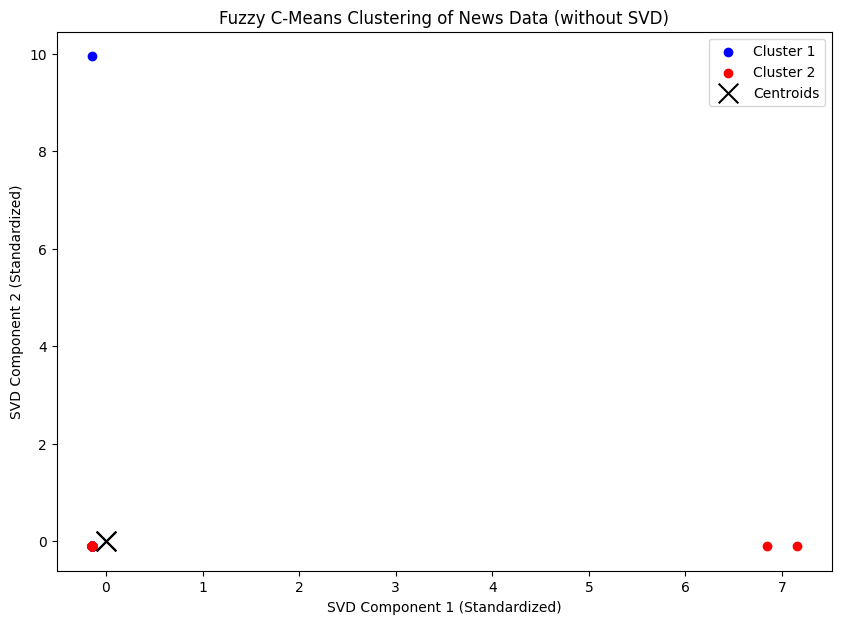

In [ ]:
n_clusters = 2  # Jumlah cluster yang diinginkan
cntr, u, _, _, _, _, _ = fuzz.cluster.cmeans(
    X_scaled.T, c=n_clusters, m=2, error=0.001, maxiter=1000, init=None
)

# Menentukan cluster untuk setiap data berdasarkan keanggotaan tertinggi
cluster_labels = np.argmax(u, axis=0)

# Visualisasi hasil klasterisasi
plt.figure(figsize=(10, 7))
colors = ['b', 'r']
for i in range(n_clusters):
    plt.scatter(X_scaled[cluster_labels == i, 0], X_scaled[cluster_labels == i, 1],
                color=colors[i], label=f'Cluster {i+1}')

# Menampilkan pusat cluster
plt.scatter(cntr[:, 0], cntr[:, 1], marker='x', s=200, color='k', label='Centroids')

plt.xlabel('SVD Component 1 (Standardized)')
plt.ylabel('SVD Component 2 (Standardized)')
plt.title('Fuzzy C-Means Clustering of News Data (without SVD)')
plt.legend()
plt.show()

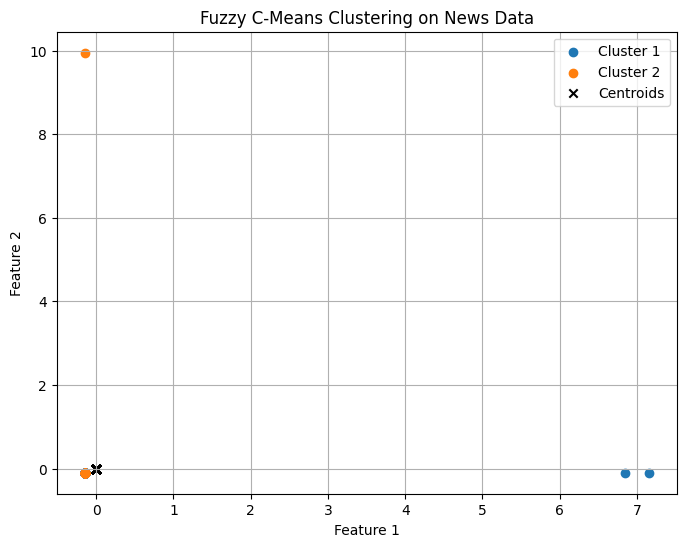

Fuzzy Partition Coefficient (FPC): 0.5000000000320959


In [ ]:
# Tentukan jumlah cluster dan parameter fuzziness
n_clusters = 2
m = 2  # Parameter fuzziness

# Terapkan Fuzzy C-Means
cntr, u, u0, d, jm, p, fpc = fuzz.cluster.cmeans(
    X_scaled.T, n_clusters, m, error=0.001, maxiter=1000, init=None
)

# Tentukan keanggotaan cluster
cluster_membership = np.argmax(u, axis=0)

# Visualisasi Hasil Clustering
plt.figure(figsize=(8, 6))
for i in range(n_clusters):
    plt.scatter(X_scaled[cluster_membership == i, 0], X_scaled[cluster_membership == i, 1], label=f'Cluster {i+1}')

# Tampilkan centroid
plt.scatter(cntr[0], cntr[1], marker='x', color='black', label='Centroids')

plt.title('Fuzzy C-Means Clustering on News Data')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.grid(True)
plt.show()

# Evaluasi Hasil
print("Fuzzy Partition Coefficient (FPC):", fpc)


# Test fuzzy c-means (SVD)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd

df = pd.read_csv("/content/drive/My Drive/PPW-A/report/Tugas-PPW/hasil_preprocesing.csv")
df.head()

,judul,isi,tanggal,kategori,Hasil cleansing,Hasil case_folding,tokenize,Hasil stopword
0,18 Tim yang Lolos FFWS Global Finals 2024 di B...,Jakarta - Rangkaian pertandingan di FFWS SEA 2...,"Rabu, 16 Okt 2024 19:30 WIB",Games,Jakarta Rangkaian pertandingan di FFWS SEA F...,jakarta rangkaian pertandingan di ffws sea f...,"['jakarta', 'rangkaian', 'pertandingan', 'di',...",jakarta rangkaian pertandingan ffws sea fall s...
1,Ampun Bang Jago! Zuckerberg Klaim Pemain Handa...,"Jakarta - CEO Meta Mark Zuckerberg, cukup perc...","Rabu, 16 Okt 2024 17:50 WIB",Games,Jakarta CEO Meta Mark Zuckerberg cukup percay...,jakarta ceo meta mark zuckerberg cukup percay...,"['jakarta', 'ceo', 'meta', 'mark', 'zuckerberg...",jakarta ceo meta mark zuckerberg percaya kemam...
2,"20 Game Horor Terbaik Tahun 2000an, Udah Perna...",Jakarta - Game horor selalu punya daya tarikny...,"Rabu, 16 Okt 2024 14:20 WIB",Games,Jakarta Game horor selalu punya daya tariknya...,jakarta game horor selalu punya daya tariknya...,"['jakarta', 'game', 'horor', 'selalu', 'punya'...",jakarta game horor daya tariknya penikmatnya b...
3,"Begini Cara Dapat Skin Zhou Yu HOK Gratis, Gam...",Jakarta - Ternyata cara dapat skin Zhou Yu Hon...,"Rabu, 16 Okt 2024 12:15 WIB",Games,Jakarta Ternyata cara dapat skin Zhou Yu Hono...,jakarta ternyata cara dapat skin zhou yu hono...,"['jakarta', 'ternyata', 'cara', 'dapat', 'skin...",jakarta skin zhou yu honor of kings hok gratis...
4,"Gagal Juara FFWS SEA 2024 Fall, Wakil RI: Kita...","Jakarta - Tampil di depan ribuan pendukungnya,...","Selasa, 15 Okt 2024 17:36 WIB",Games,Jakarta Tampil di depan ribuan pendukungnya t...,jakarta tampil di depan ribuan pendukungnya t...,"['jakarta', 'tampil', 'di', 'depan', 'ribuan',...",jakarta tampil ribuan pendukungnya wakil indon...


In [ ]:
!pip install scikit-fuzzy
# Import libraries yang diperlukan
import numpy as np
import pandas as pd
import skfuzzy as fuzz
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import StandardScaler

In [ ]:
texts = df['Hasil stopword']

In [ ]:
# Preprocessing: TF-IDF
tfidf = TfidfVectorizer()
tfidf_matrix = tfidf.fit_transform(texts)
tfidf_array = tfidf_matrix.toarray()

In [ ]:
# Reduksi dimensi menggunakan SVD
svd = TruncatedSVD(n_components=10, random_state=0)
data_2d = svd.fit_transform(tfidf_array)

In [ ]:
# Normalisasi dengan StandardScaler
scaler = StandardScaler()
data_2d_normalized = scaler.fit_transform(data_2d)

In [ ]:
import numpy as np
import skfuzzy as fuzz
from sklearn.preprocessing import StandardScaler

# Anggap data_2d_normalized adalah hasil reduksi dimensi dan normalisasi data
np.random.seed(25)
n_clusters = 2

# Fuzzy C-Means Clustering
cntr, u, _, _, _, _, _ = fuzz.cluster.cmeans(
    data_2d_normalized.T, c=n_clusters, m=7, error=0.001, maxiter=1000, init=None
)

# Menentukan cluster untuk setiap data berdasarkan keanggotaan tertinggi
cluster_labels = np.argmax(u, axis=0)

# Menambahkan hasil klasterisasi ke dalam DataFrame
df['Cluster'] = cluster_labels

# Menampilkan jumlah data pada setiap cluster
cluster_counts = df['Cluster'].value_counts()
print("Jumlah data pada setiap cluster:")
print(cluster_counts)

Jumlah data pada setiap cluster:
Cluster
1    55
0    45
Name: count, dtype: int64


In [ ]:
# Menambahkan hasil klasterisasi ke dalam DataFrame
df['Cluster'] = cluster_labels
df

,judul,isi,tanggal,kategori,Hasil cleansing,Hasil case_folding,tokenize,Hasil stopword,Cluster
0,18 Tim yang Lolos FFWS Global Finals 2024 di B...,Jakarta - Rangkaian pertandingan di FFWS SEA 2...,"Rabu, 16 Okt 2024 19:30 WIB",Games,Jakarta Rangkaian pertandingan di FFWS SEA F...,jakarta rangkaian pertandingan di ffws sea f...,"['jakarta', 'rangkaian', 'pertandingan', 'di',...",jakarta rangkaian pertandingan ffws sea fall s...,0
1,Ampun Bang Jago! Zuckerberg Klaim Pemain Handa...,"Jakarta - CEO Meta Mark Zuckerberg, cukup perc...","Rabu, 16 Okt 2024 17:50 WIB",Games,Jakarta CEO Meta Mark Zuckerberg cukup percay...,jakarta ceo meta mark zuckerberg cukup percay...,"['jakarta', 'ceo', 'meta', 'mark', 'zuckerberg...",jakarta ceo meta mark zuckerberg percaya kemam...,1
2,"20 Game Horor Terbaik Tahun 2000an, Udah Perna...",Jakarta - Game horor selalu punya daya tarikny...,"Rabu, 16 Okt 2024 14:20 WIB",Games,Jakarta Game horor selalu punya daya tariknya...,jakarta game horor selalu punya daya tariknya...,"['jakarta', 'game', 'horor', 'selalu', 'punya'...",jakarta game horor daya tariknya penikmatnya b...,1
3,"Begini Cara Dapat Skin Zhou Yu HOK Gratis, Gam...",Jakarta - Ternyata cara dapat skin Zhou Yu Hon...,"Rabu, 16 Okt 2024 12:15 WIB",Games,Jakarta Ternyata cara dapat skin Zhou Yu Hono...,jakarta ternyata cara dapat skin zhou yu hono...,"['jakarta', 'ternyata', 'cara', 'dapat', 'skin...",jakarta skin zhou yu honor of kings hok gratis...,1
4,"Gagal Juara FFWS SEA 2024 Fall, Wakil RI: Kita...","Jakarta - Tampil di depan ribuan pendukungnya,...","Selasa, 15 Okt 2024 17:36 WIB",Games,Jakarta Tampil di depan ribuan pendukungnya t...,jakarta tampil di depan ribuan pendukungnya t...,"['jakarta', 'tampil', 'di', 'depan', 'ribuan',...",jakarta tampil ribuan pendukungnya wakil indon...,0
...,...,...,...,...,...,...,...,...,...
95,Rating Pemain China Vs Indonesia: Thom Haye Te...,Jakarta - China vs Indonesia tuntas 2-1 di lan...,"Rabu, 16 Okt 2024 12:00 WIB",Sepak Bola,Jakarta China vs Indonesia tuntas di lanjuta...,jakarta china vs indonesia tuntas di lanjuta...,"['jakarta', 'china', 'vs', 'indonesia', 'tunta...",jakarta china vs indonesia tuntas lanjutan kua...,0
96,China Vs Indonesia: Coret Eliano Reijnders Blu...,Qingdao - Keputusan mencoret Eliano Reijnders ...,"Rabu, 16 Okt 2024 11:40 WIB",Sepak Bola,Qingdao Keputusan mencoret Eliano Reijnders s...,qingdao keputusan mencoret eliano reijnders s...,"['qingdao', 'keputusan', 'mencoret', 'eliano',...",qingdao keputusan mencoret eliano reijnders me...,0
97,Dumfries Akui Performanya Lebih Baik di Timnas...,"Jakarta - Denzel Dumfries mengakui, performany...","Rabu, 16 Okt 2024 11:20 WIB",Sepak Bola,Jakarta Denzel Dumfries mengakui performanya ...,jakarta denzel dumfries mengakui performanya ...,"['jakarta', 'denzel', 'dumfries', 'mengakui', ...",jakarta denzel dumfries mengakui performanya t...,1
98,Hasil Lengkap-Klasemen Kualifikasi Piala Dunia...,Jakarta - Matchday 4 di babak ketiga kualifika...,"Rabu, 16 Okt 2024 11:00 WIB",Sepak Bola,Jakarta Matchday di babak ketiga kualifikasi...,jakarta matchday di babak ketiga kualifikasi...,"['jakarta', 'matchday', 'di', 'babak', 'ketiga...",jakarta matchday babak ketiga kualifikasi pial...,0


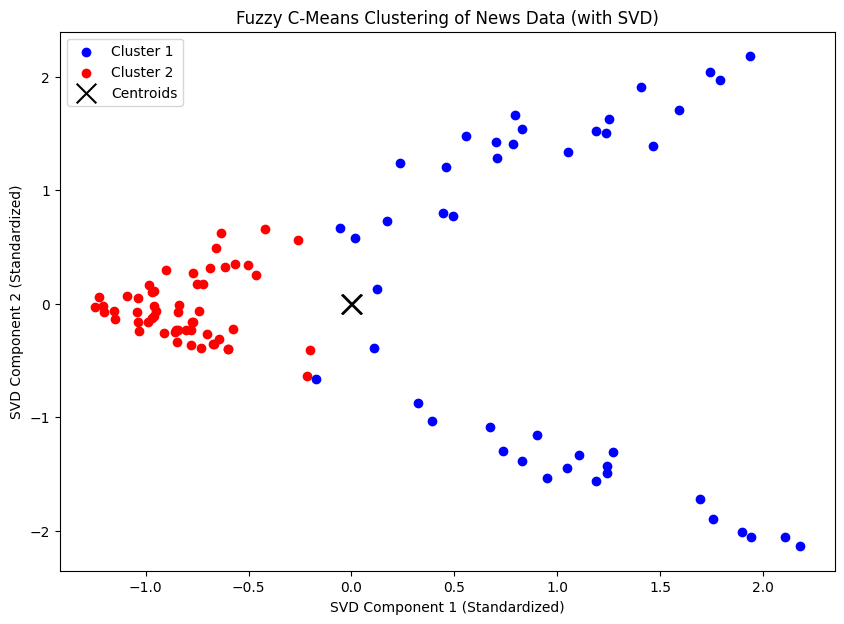

In [ ]:
# Visualisasi hasil klasterisasi
plt.figure(figsize=(10, 7))
colors = ['b', 'r']
for i in range(n_clusters):
    plt.scatter(data_2d_normalized[cluster_labels == i, 0], data_2d_normalized[cluster_labels == i, 1],
                color=colors[i], label=f'Cluster {i+1}')

# Menampilkan pusat cluster
plt.scatter(cntr[:, 0], cntr[:, 1], marker='x', s=200, color='k', label='Centroids')

plt.xlabel('SVD Component 1 (Standardized)')
plt.ylabel('SVD Component 2 (Standardized)')
plt.title('Fuzzy C-Means Clustering of News Data (with SVD)')
plt.legend()
plt.show()

In [ ]:
from sklearn.metrics import silhouette_score, adjusted_rand_score

# Perhitungan silhouette score
sil_score = silhouette_score(data_2d_normalized, cluster_labels)
print(f"Silhouette Score: {sil_score}")

# Menambahkan kategori asli (Game atau Sepakbola) ke DataFrame
categories = df['kategori']

# Evaluasi kesesuaian cluster dengan kategori asli
ari_score = adjusted_rand_score(categories, cluster_labels)
print(f"Adjusted Rand Index (ARI): {ari_score}")


Silhouette Score: 0.17025244256098346
Adjusted Rand Index (ARI): -0.009696969696969697


# Test fuzzy c-means 3

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd

df = pd.read_csv("/content/drive/My Drive/PPW-A/report/Tugas-PPW/hasil_preprocesing.csv")
df.head()

,judul,isi,tanggal,kategori,Hasil cleansing,Hasil case_folding,tokenize,Hasil stopword
0,18 Tim yang Lolos FFWS Global Finals 2024 di B...,Jakarta - Rangkaian pertandingan di FFWS SEA 2...,"Rabu, 16 Okt 2024 19:30 WIB",Games,Jakarta Rangkaian pertandingan di FFWS SEA F...,jakarta rangkaian pertandingan di ffws sea f...,"['jakarta', 'rangkaian', 'pertandingan', 'di',...",jakarta rangkaian pertandingan ffws sea fall s...
1,Ampun Bang Jago! Zuckerberg Klaim Pemain Handa...,"Jakarta - CEO Meta Mark Zuckerberg, cukup perc...","Rabu, 16 Okt 2024 17:50 WIB",Games,Jakarta CEO Meta Mark Zuckerberg cukup percay...,jakarta ceo meta mark zuckerberg cukup percay...,"['jakarta', 'ceo', 'meta', 'mark', 'zuckerberg...",jakarta ceo meta mark zuckerberg percaya kemam...
2,"20 Game Horor Terbaik Tahun 2000an, Udah Perna...",Jakarta - Game horor selalu punya daya tarikny...,"Rabu, 16 Okt 2024 14:20 WIB",Games,Jakarta Game horor selalu punya daya tariknya...,jakarta game horor selalu punya daya tariknya...,"['jakarta', 'game', 'horor', 'selalu', 'punya'...",jakarta game horor daya tariknya penikmatnya b...
3,"Begini Cara Dapat Skin Zhou Yu HOK Gratis, Gam...",Jakarta - Ternyata cara dapat skin Zhou Yu Hon...,"Rabu, 16 Okt 2024 12:15 WIB",Games,Jakarta Ternyata cara dapat skin Zhou Yu Hono...,jakarta ternyata cara dapat skin zhou yu hono...,"['jakarta', 'ternyata', 'cara', 'dapat', 'skin...",jakarta skin zhou yu honor of kings hok gratis...
4,"Gagal Juara FFWS SEA 2024 Fall, Wakil RI: Kita...","Jakarta - Tampil di depan ribuan pendukungnya,...","Selasa, 15 Okt 2024 17:36 WIB",Games,Jakarta Tampil di depan ribuan pendukungnya t...,jakarta tampil di depan ribuan pendukungnya t...,"['jakarta', 'tampil', 'di', 'depan', 'ribuan',...",jakarta tampil ribuan pendukungnya wakil indon...


In [ ]:
!pip install scikit-fuzzy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.feature_extraction.text import TfidfVectorizer
import skfuzzy as fuzz

In [ ]:
# Lakukan preprocessing data menggunakan TF-IDF
tfidf = TfidfVectorizer()
X = tfidf.fit_transform(df['Hasil stopword']).toarray()

In [ ]:
lda = LatentDirichletAllocation(n_components=5)
X_topic = lda.fit_transform(X)

# Normalisasi fitur
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_normalized = scaler.fit_transform(X_topic)

In [ ]:


# Implementasikan Fuzzy C-Means menggunakan Fuzzy library
n_clusters = 2
m = 8  # Fuzzy coefficient
max_iter = 1000
tol = 0.0005

cntr, u, _, _, _, _, _ = fuzz.cluster.cmeans(X_normalized.T, n_clusters, m, max_iter, tol)

# Dapatkan label cluster untuk setiap data
labels = np.argmax(u, axis=0)



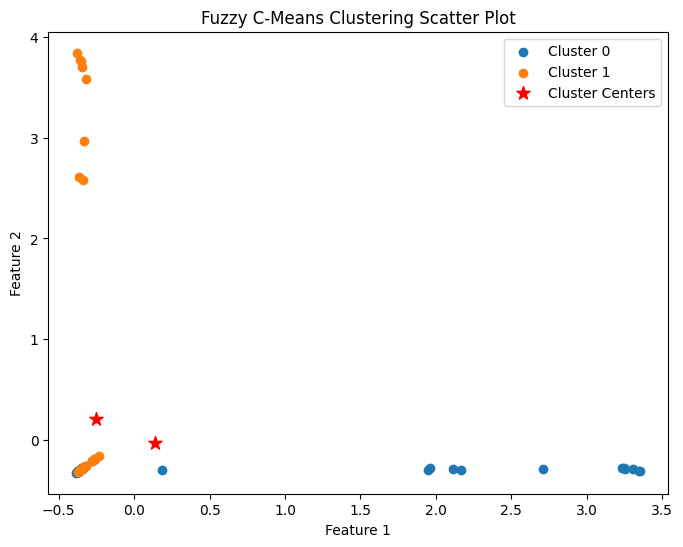

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Buat plot scatter
plt.figure(figsize=(8, 6))
for i in range(n_clusters):
    cluster_data = X_normalized[labels == i]
    plt.scatter(cluster_data[:, 0], cluster_data[:, 1], label=f'Cluster {i}')
plt.scatter(cntr[:, 0], cntr[:, 1], s=100, c='red', marker='*', label='Cluster Centers')
plt.title('Fuzzy C-Means Clustering Scatter Plot')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.show()